# DGMF-Net

## DSM-5 Guided Graph-Based Multi-View Feature Learning Framework

### ADHD • ASD • AuDHD Prediction using NSCH Dataset


## Workflow

1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. TabDDPM Imputation
5. DSM-5 Feature Engineering
6. Clinical Risk Score Generation
7. Graph Construction
8. Graph Autoencoder
9. Multi-View Feature Fusion
10. BorutaSHAP Feature Selection
11. CatBoost & XGBoost
12. Optuna + NSGA-II
13. Explainable AI
14. Final Evaluation

In [1]:
# =============================================================================
# SECTION 1 : IMPORT LIBRARIES
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import sys
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

print("=" * 80)
print("DGMF-Net Framework")
print("=" * 80)

print(f"Python Version : {sys.version}")
print(f"NumPy Version  : {np.__version__}")
print(f"Pandas Version : {pd.__version__}")

DGMF-Net Framework
Python Version : 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
NumPy Version  : 1.26.4
Pandas Version : 2.3.3


In [2]:
# =============================================================================
# SECTION 2 : PROJECT SETUP76
# =============================================================================

import os
import sys

# Get the project root (one level above the notebooks folder)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project Root:", PROJECT_ROOT)

Project Root: c:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD


In [3]:
from src import config

print("config.py imported successfully!")

config.py imported successfully!


In [4]:
# =============================================================================
# SECTION 3 : DATA LOADING
# =============================================================================

from src.data_loader import load_nsch_data, dataset_summary

df, variable_labels = load_nsch_data()

dataset_summary(df)

Loading NSCH 2023-2024 Dataset...
Dataset Loaded Successfully
Dataset Shape : (106537, 890)

Variable Labels Loaded Successfully
Number of Variables : 890

DATASET SUMMARY

Dataset Shape
(106537, 890)

Dataset Information
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106537 entries, 0 to 106536
Columns: 890 entries, HEIGHT to smForgoneHC_2324
dtypes: float64(3), int64(885), object(2)
memory usage: 723.4+ MB

Missing Values (Top 20)
--------------------------------------------------------------------------------
HEIGHT                 0
ASDSevInd_2324         0
curious6to17_2324      0
finishes_2324          0
resil6to17_2324        0
flourish6mto17_2324    0
argue_2324             0
MakeFriend_2324        0
ADHDind_2324           0
ADHDSevInd_2324        0
ADHDMed_2324           0
ADHDBehTreat_2324      0
AutismInd_2324         0
ASDMed_2324            0
flrsh6to17ct           0
ASDBehTreat_2324       

In [5]:
# =============================================================================
# SECTION 4 : DATA AUDIT
# =============================================================================

from src.audit import run_data_audit

audit_report = run_data_audit(df)

SECTION 4 : DATA AUDIT

Dataset Shape
------------------------------------------------------------------------------------------
(106537, 890)

Duplicate Rows
------------------------------------------------------------------------------------------
0

Data Types
------------------------------------------------------------------------------------------
int64      885
float64      3
object       2
Name: count, dtype: int64

Numeric Columns : 888
Categorical Columns : 2

Memory Usage
------------------------------------------------------------------------------------------
733.60 MB

Constant Columns : 1
High Cardinality Columns : 9

Encoded Missing Value Report
------------------------------------------------------------------------------------------
99       : 934054
999      : 7272
9999     : 9422
9990     : 70730

Columns containing 9990
------------------------------------------------------------------------------------------
['HEIGHT', 'WEIGHT']

Columns containing 9999
-----------

In [6]:
# =============================================================================
# SECTION 5 : DATA CLEANING
# =============================================================================

from src.preprocessing import clean_data

clean_df = clean_data(df)

SECTION 5 : DATA CLEANING

Duplicate Rows Removed : 0

Replacing Encoded Missing Values...

Replacement Summary
HEIGHT          : 37983
WEIGHT          : 36885

Original Shape : (106537, 890)
Cleaned Shape  : (106537, 890)

Cleaned dataset saved successfully.
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\data\processed\NSCH_2023_2024_Cleaned.csv


In [7]:
# =============================================================================
# SECTION 6 : EXPLORATORY DATA ANALYSIS
# =============================================================================

from src.eda import dataset_overview

overview = dataset_overview(clean_df)

SECTION 6 : EXPLORATORY DATA ANALYSIS

Dataset Shape
------------------------------------------------------------------------------------------
(106537, 890)

Number of Features : 890
Number of Samples : 106537

Numeric Features : 888
Categorical Features : 2

Memory Usage
733.60 MB

Top 20 Columns
['HEIGHT', 'FIPSST', 'STRATUM', 'HHID', 'FORMTYPE', 'TOTKIDS_R', 'TENURE', 'HHLANGUAGE', 'SC_AGE_YEARS', 'SC_SEX', 'K2Q35A_1_YEARS', 'BIRTH_MO', 'BIRTH_YR', 'K6Q41R_STILL', 'K6Q42R_NEVER', 'K6Q43R_NEVER', 'K6Q13A', 'K6Q13B', 'K6Q14A', 'K6Q14B']



MISSING VALUE ANALYSIS

Missing Value Table Saved:
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\outputs\tables\missing_values.csv

Top 20 Missing Columns
        Missing Values  Percentage (%)
HEIGHT           37983           35.65
WEIGHT           36885           34.62


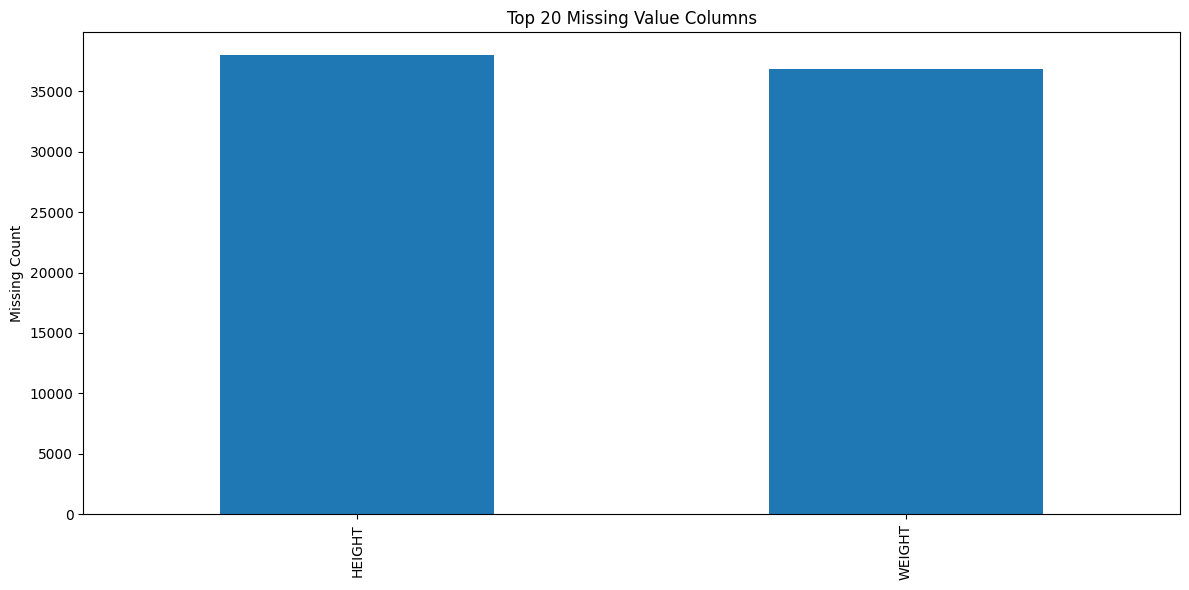


Figure Saved:
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\figures\missing_values.png


In [8]:
# =============================================================================
# SECTION 6.2 : MISSING VALUE ANALYSIS
# =============================================================================

from src.eda import missing_value_analysis

missing_table = missing_value_analysis(clean_df)


HEIGHT ANALYSIS

Summary Statistics
------------------------------------------------------------------------------------------
count    68554.000000
mean       152.571850
std         20.209974
min         93.980000
25%        137.160000
50%        154.940000
75%        167.640000
max        211.050000
Name: HEIGHT, dtype: float64

Missing Values
37983


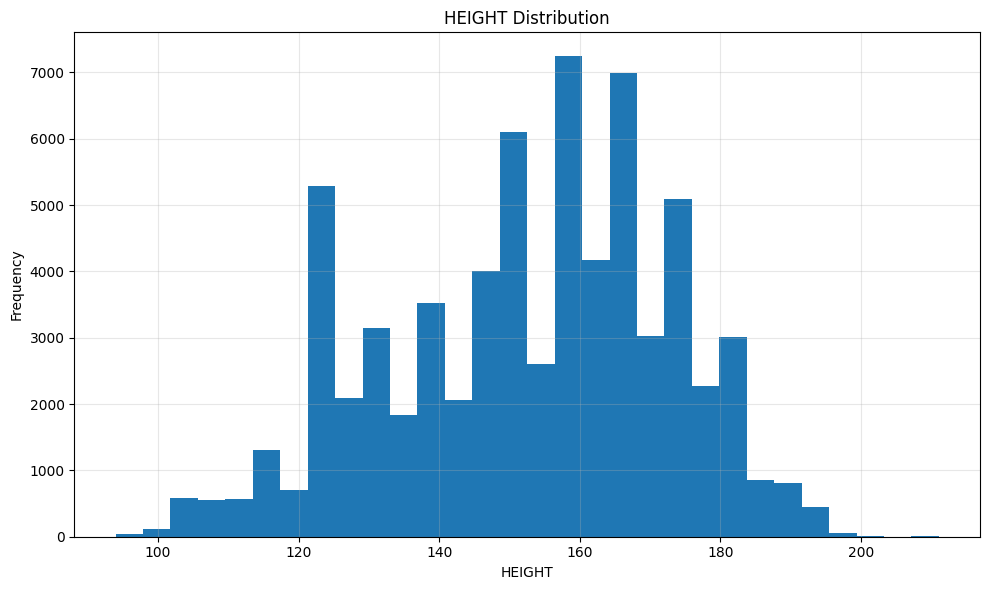


Histogram Saved:
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\figures\height_distribution.png


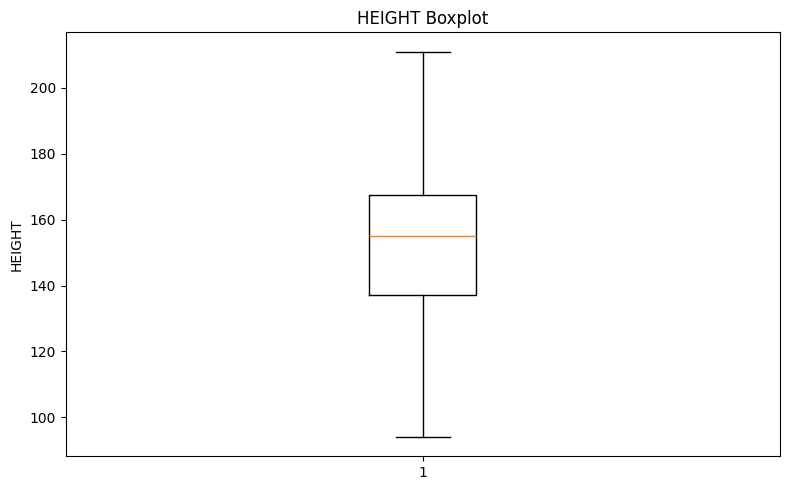


Boxplot Saved:
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\figures\height_boxplot.png


In [9]:
# =============================================================================
# SECTION 6.3 : HEIGHT ANALYSIS
# =============================================================================

from src.eda import plot_numeric_distribution

plot_numeric_distribution(clean_df, "HEIGHT")


WEIGHT ANALYSIS

Summary Statistics
------------------------------------------------------------------------------------------
count    69652.000000
mean        49.052628
std         20.573279
min         11.340000
25%         31.750000
50%         47.630001
75%         61.230000
max        140.460000
Name: WEIGHT, dtype: float64

Missing Values
36885


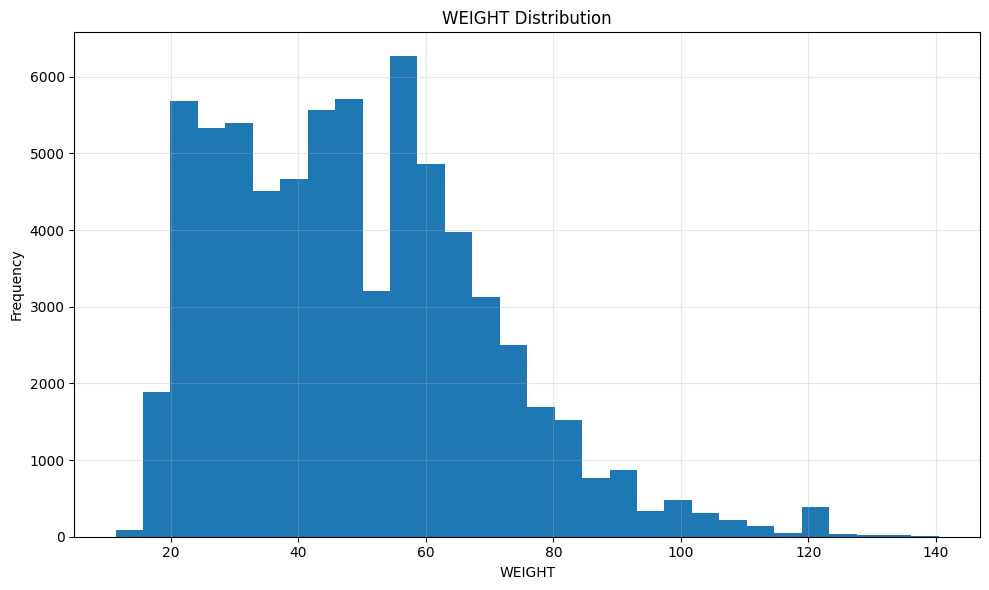


Histogram Saved:
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\figures\weight_distribution.png


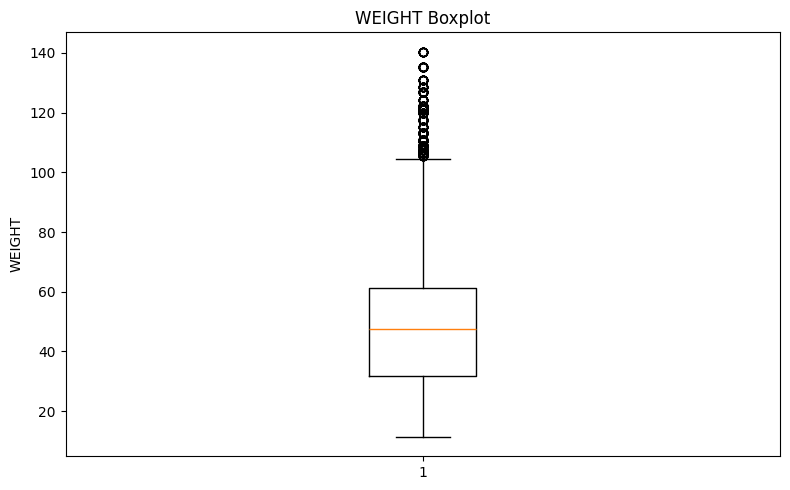


Boxplot Saved:
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\figures\weight_boxplot.png


In [10]:
# =============================================================================
# SECTION 6.4 : WEIGHT ANALYSIS
# =============================================================================

plot_numeric_distribution(clean_df, "WEIGHT")

In [11]:
# =============================================================================
# SECTION 6.5 : NUMERICAL FEATURE SUMMARY
# =============================================================================

from src.eda import numerical_summary

numerical_report = numerical_summary(clean_df)


NUMERICAL FEATURE SUMMARY

Summary saved to:
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\outputs\tables\numerical_summary.csv

Top 20 Features
                 Feature Data Type  Missing Values  Missing (%)        Mean  \
0                 HEIGHT   float64           37983        35.65  152.571850   
443               WEIGHT   float64           36885        34.62   49.052628   
886       smAdeqIns_2324     int64               0         0.00    1.997043   
596       ASDSevInd_2324     int64               0         0.00   15.508086   
585    curious6to17_2324     int64               0         0.00   31.727550   
586        finishes_2324     int64               0         0.00   32.091818   
587      resil6to17_2324     int64               0         0.00   32.227977   
588  flourish6mto17_2324     int64               0         0.00    4.866441   
589           argue_2324     int64               0         0.00   32.820166   
590      MakeFriend_2324     int64               0        

In [12]:
target_columns = [
    "ADHDind_2324",
    "AutismInd_2324"
]

for col in target_columns:
    print(col, "->", col in clean_df.columns)

ADHDind_2324 -> True
AutismInd_2324 -> True


In [13]:
from src.config import PROJECT_ROOT

print(PROJECT_ROOT)

C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD


In [14]:
# =============================================================================
# SECTION 7 : TARGET CREATION
# =============================================================================

from src.target import create_target_dataset

target_df = create_target_dataset(clean_df)

SECTION 7 : TARGET CREATION
Valid Samples : 89,464

Target Distribution
------------------------------------------------------------------------------------------
TARGET_NAME
Healthy    75888
ADHD        9466
ASD         2114
AuDHD       1996
Name: count, dtype: int64

Dataset Saved
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\data\processed\NSCH_Target_Dataset.csv


In [15]:
# =============================================================================
# SECTION 8.1 : TABDDPM DATASET PREPARATION
# =============================================================================

from src.tabddpm.dataset import prepare_tabddpm_dataset

tabddpm_path = prepare_tabddpm_dataset(target_df)

SECTION 8.1 : TABDDPM DATASET PREPARATION
Training Samples   : 62,624
Validation Samples : 13,420
Testing Samples    : 13,420

Numerical Features : 888
Categorical Features : 2

Dataset saved to
C:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\external\TabDDPM\data\NSCH_TabDDPM


In [16]:
X = target_df.drop(
    columns=["TARGET", "TARGET_NAME"]
)

from src.feature_selection.dataset import remove_leakage_features

X, existing = remove_leakage_features(X)

print("Removed columns:")
print(existing)

print("\nNew shape:", X.shape)

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))


Removed columns:
['ADHDind_2324', 'ADHDSevInd_2324', 'ADHDMed_2324', 'ADHDBehTreat_2324', 'AutismInd_2324', 'ASDSevInd_2324', 'ASDMed_2324', 'ASDBehTreat_2324', 'ASDAge_2324', 'ASDDrType_2324', 'MEDB10ScrQ5_2324']

New shape: (89464, 879)
Numerical: 877
Categorical: 2


In [17]:
print("ADHDInd_2324 in X:", "ADHDInd_2324" in X.columns)
print("MEDB10ScrQ5_2324 in X:", "MEDB10ScrQ5_2324" in X.columns)

ADHDInd_2324 in X: False
MEDB10ScrQ5_2324 in X: False


In [18]:

# =============================================================================
# SECTION 8.2 : VERIFY TABDDPM GENERATED DATA
# =============================================================================

import numpy as np

base_path = "../external/TabDDPM/exp/NSCH/ddpm_cb_best"

X_num = np.load(f"{base_path}/X_num_train.npy")
X_cat = np.load(f"{base_path}/X_cat_train.npy", allow_pickle=True)
y = np.load(f"{base_path}/y_train.npy")

print("="*70)
print("TABDDPM GENERATED DATA")
print("="*70)

print("X_num shape :", X_num.shape)
print("X_cat shape :", X_cat.shape)
print("y shape     :", y.shape)

TABDDPM GENERATED DATA
X_num shape : (90000, 888)
X_cat shape : (90000, 2)
y shape     : (90000,)


In [19]:
import pandas as pd

print("=" * 70)
print("SYNTHETIC TARGET DISTRIBUTION")
print("=" * 70)

print(pd.Series(y).value_counts().sort_index())

SYNTHETIC TARGET DISTRIBUTION
0    76325
1     9499
2     2125
3     2051
Name: count, dtype: int64


In [20]:
target_map = {
    0: "Healthy",
    1: "ADHD",
    2: "ASD",
    3: "AuDHD"
}

print("\nHuman Readable Distribution:\n")
print(pd.Series(y).map(target_map).value_counts())


Human Readable Distribution:

Healthy    76325
ADHD        9499
ASD         2125
AuDHD       2051
Name: count, dtype: int64


In [21]:
for col in target_df.columns:
    if "CONCENT" in col.upper():
        print(col)

In [22]:
for col in target_df.columns:
    if "FRIEND" in col.upper():
        print(col)

MAKEFRIEND
MakeFriend_2324


In [23]:
for col in target_df.columns:
    if "BULL" in col.upper():
        print(col)

BULLIED_R
BULLY
bully_2324
bullied_2324
npmBullied12to17_2324
npmBullied12to17CSHCN_2324
npmBully12to17_2324
npmBully12to17CSHCN_2324


In [24]:
for col in target_df.columns:
    if "BEHAV" in col.upper():
        print(col)

behavior_2324
BehavSev_2324
nomBehavior6to11_2324


In [25]:
for col in target_df.columns:
    if "SCHOOL" in col.upper():
        print(col)

STARTSCHOOL
SchoolReadiness_2324
nomSchoolReadiness2_2324


In [26]:
keywords = [
    "ATTEN",
    "FOCUS",
    "CONC",
    "FORGET",
    "IMPUL",
    "HYPER",
    "RESTLESS",
    "SENS",
    "REPET",
    "AUTISM",
    "ADHD"
]

for key in keywords:
    print(f"\n===== {key} =====")
    found = False
    for col in target_df.columns:
        if key in col.upper():
            print(col)
            found = True
    if not found:
        print("No columns found.")


===== ATTEN =====
No columns found.

===== FOCUS =====
FOCUSON
FocusOn_2324

===== CONC =====
CONCUSSION
ENGAGECONCERN
RAISECONC
WGTCONC
WgtConcn_2324
DrAskConc_2324
RaiseConc_2324

===== FORGET =====
No columns found.

===== IMPUL =====
No columns found.

===== HYPER =====
No columns found.

===== RESTLESS =====
No columns found.

===== SENS =====
sensitiv_2324

===== REPET =====
No columns found.

===== AUTISM =====
AUTISMMED
AUTISMTREAT
autism_2324
AutismSev_2324
AutismInd_2324

===== ADHD =====
ADHD_2324
ADHDSev_2324
ADHDind_2324
ADHDSevInd_2324
ADHDMed_2324
ADHDBehTreat_2324


In [27]:
candidate_columns = [
    "FOCUSON",
    "FocusOn_2324",
    "MAKEFRIEND",
    "BULLIED_R",
    "behavior_2324",
    "BehavSev_2324",
    "SchoolReadiness_2324"
]

target_df[candidate_columns].head()

,FOCUSON,FocusOn_2324,MAKEFRIEND,BULLIED_R,behavior_2324,BehavSev_2324,SchoolReadiness_2324
0,90,90,2,1,3,3,90
3,90,90,1,1,1,1,90
4,2,2,90,90,1,1,3
5,1,1,90,90,1,1,3
6,90,90,1,1,1,1,90


In [28]:
for col in candidate_columns:
    print(f"\n===== {col} =====")
    print(target_df[col].value_counts(dropna=False).head(10))


===== FOCUSON =====
FOCUSON
90    70126
2      8195
1      7247
3      1877
4      1429
99      352
5       238
Name: count, dtype: int64

===== FocusOn_2324 =====
FocusOn_2324
90    70126
2      8195
1      7247
3      1877
4      1429
99      352
5       238
Name: count, dtype: int64

===== MAKEFRIEND =====
MAKEFRIEND
1     50542
90    19338
2     14645
3      4045
99      894
Name: count, dtype: int64

===== BULLIED_R =====
BULLIED_R
1     38761
2     20850
90    19338
3      5435
4      2697
5      1393
99      990
Name: count, dtype: int64

===== behavior_2324 =====
behavior_2324
1     80292
3      7306
2      1667
99      199
Name: count, dtype: int64

===== BehavSev_2324 =====
BehavSev_2324
1     81959
3      3772
2      3503
99      230
Name: count, dtype: int64

===== SchoolReadiness_2324 =====
SchoolReadiness_2324
90    70126
3     13272
2      4811
1      1255
Name: count, dtype: int64


In [29]:
dsm5_candidates = [
    "ADHDind_2324",
    "ADHDSevInd_2324",
    "AutismInd_2324",
    "ASDSevInd_2324",
    "MEDB10ScrQ5_2324",
    "SchoolReadiness_2324",
    "MakeFriend_2324",
    "bullied_2324"
]

for col in dsm5_candidates:
    print(col, ":", col in target_df.columns)

ADHDind_2324 : True
ADHDSevInd_2324 : True
AutismInd_2324 : True
ASDSevInd_2324 : True
MEDB10ScrQ5_2324 : True
SchoolReadiness_2324 : True
MakeFriend_2324 : True
bullied_2324 : True


In [30]:
from src.dsm5.mapping import map_dsm5_domains
from src.dsm5.scoring import compute_dsm5_scores

In [31]:
dsm5_df = map_dsm5_domains(target_df)

In [32]:
print(dsm5_df.shape)

(89464, 9)


In [33]:
dsm5_df.head()

,ADHDind_2324,ADHDSevInd_2324,SchoolReadiness_2324,MEDB10ScrQ5_2324,ADHDBehTreat_2324,MakeFriend_2324,bullied_2324,AutismInd_2324,ASDSevInd_2324
0,3,3,90,1,1,2,1,3,3
3,1,1,90,2,3,1,1,1,1
4,1,1,3,2,3,90,90,1,1
5,1,1,3,2,3,90,90,1,1
6,1,1,90,2,3,1,1,1,1


In [34]:
risk_scores = compute_dsm5_scores(dsm5_df)

In [35]:
from src.graph.constructor import build_graph_dataset

In [36]:
graphs, edge_index = build_graph_dataset(dsm5_df)

In [37]:
from src.graph.autoencoder import build_autoencoder

model = build_autoencoder()

print(model)

GAE(
  (encoder): GCNEncoder(
    (conv1): GCNConv(1, 16)
    (conv2): GCNConv(16, 8)
  )
  (decoder): InnerProductDecoder()
)


In [38]:
from src.graph.trainer import train_autoencoder

In [39]:
trained_model, loss_history = train_autoencoder(
    model,
    graphs
)

Epoch 001/100 | Loss = 1.994555
Epoch 002/100 | Loss = 1.155705
Epoch 003/100 | Loss = 1.156166
Epoch 004/100 | Loss = 1.157093
Epoch 005/100 | Loss = 1.155282
Epoch 006/100 | Loss = 1.155999
Epoch 007/100 | Loss = 1.154379
Epoch 008/100 | Loss = 1.156306
Epoch 009/100 | Loss = 1.155313
Epoch 010/100 | Loss = 1.155653
Epoch 011/100 | Loss = 1.154268
Epoch 012/100 | Loss = 1.153794
Epoch 013/100 | Loss = 1.154692
Epoch 014/100 | Loss = 1.140908
Epoch 015/100 | Loss = 1.046741
Epoch 016/100 | Loss = 1.028635
Epoch 017/100 | Loss = 1.028466
Epoch 018/100 | Loss = 1.028190
Epoch 019/100 | Loss = 1.027493
Epoch 020/100 | Loss = 1.028005
Epoch 021/100 | Loss = 1.026613
Epoch 022/100 | Loss = 1.026666
Epoch 023/100 | Loss = 1.027595
Epoch 024/100 | Loss = 1.026958
Epoch 025/100 | Loss = 1.026103
Epoch 026/100 | Loss = 1.025626
Epoch 027/100 | Loss = 1.027248
Epoch 028/100 | Loss = 1.026437
Epoch 029/100 | Loss = 1.026795
Epoch 030/100 | Loss = 1.026627
Epoch 031/100 | Loss = 1.026293
Epoch 03

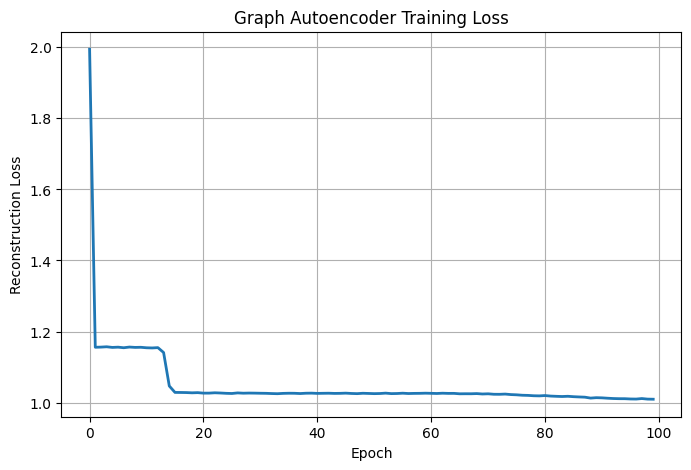

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_history, linewidth=2)

plt.title("Graph Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")

plt.grid(True)

plt.show()

In [41]:
from src.graph.embeddings import extract_embeddings


In [42]:
embedding_df = extract_embeddings(
    trained_model,
    graphs
)

In [43]:
from src.fusion.feature_fusion import fuse_features

In [44]:
fused_df = fuse_features(
    dsm5_df,
    embedding_df
)

In [45]:
X = fused_df.copy()

y = target_df["TARGET_NAME"]

In [46]:
# =============================================================================
# Remove Leakage Features
# =============================================================================

from src.feature_selection.dataset import remove_leakage_features

X, existing = remove_leakage_features(X)

print("Columns removed:")
print(existing)

print("\nNew shape:", X.shape)


Columns removed:
['ADHDind_2324', 'ADHDSevInd_2324', 'MEDB10ScrQ5_2324', 'ADHDBehTreat_2324', 'AutismInd_2324', 'ASDSevInd_2324']

New shape: (89464, 11)


In [47]:
# ============================================================
# Remove Diagnosis Leakage Features
# ============================================================

from src.feature_selection.dataset import remove_leakage_features

X, existing = remove_leakage_features(X)

print("Removed diagnosis leakage columns:")
print(existing)


Removed diagnosis leakage columns:
[]


In [48]:
leakage_features = [
    "ADHDInd_2324",
    "ADHDSevInd_2324",
    "ADHDMed_2324",
    "ADHDBehTreat_2324",
    "AutismInd_2324",
    "ASDSevInd_2324",
    "ASDMed_2324",
    "ASDBehTreat_2324",
    "ASDAge_2324",
    "ASDDrType_2324",
    "MEDB10ScrQ5_2324"
]



existing = [
    c for c in leakage_features
    if c in X.columns
]

X = X.drop(
    columns=existing
)

In [49]:
from sklearn.model_selection import train_test_split

from src.feature_selection.encoder import encode_target

y_encoded, label_encoder = encode_target(y)

X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (71571, 11)
Test shape : (17893, 11)


In [50]:
from src.feature_selection.stability import stability_selection

In [51]:
# =============================================================================
# SECTION 17 : Bootstrap BorutaSHAP
# =============================================================================

from src.feature_selection.bootstrap_stability import (
    bootstrap_sample,
    run_one_iteration
)

In [52]:
X_boot, y_boot = bootstrap_sample(
    X_train,
    y_train_encoded,
    random_state=42
)

In [53]:
print(X_boot.shape)
print(y_boot.shape)

(71571, 11)
(71571,)


In [54]:
features = run_one_iteration(
    X_train,
    y_train_encoded,
    seed=42
)

SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)


In [55]:
print(len(features))
print(features)

11
['GAE_Embedding_4', 'GAE_Embedding_5', 'GAE_Embedding_7', 'GAE_Embedding_6', 'GAE_Embedding_2', 'GAE_Embedding_3', 'GAE_Embedding_1', 'GAE_Embedding_8', 'MakeFriend_2324', 'SchoolReadiness_2324', 'bullied_2324']


In [56]:
selected_feature_lists = [
    features
]

single_iter_stable_features, single_iter_stability_df = stability_selection(
    selected_feature_lists,
    threshold=0.80
)

print("Selected feature lists created from a single bootstrap iteration.")

Selected feature lists created from a single bootstrap iteration.


In [57]:
# =============================================================================
# SECTION 18 : Real Bootstrap Stability Selection
# =============================================================================

from src.feature_selection.bootstrap_stability import (
    bootstrap_stability_selection
)

In [58]:
stable_features, stability_df = bootstrap_stability_selection(
    X_train,
    y_train_encoded,
    n_iterations=30,
    threshold=0.80,
    random_state=42
)

Bootstrap Iteration 1/30
SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)
Bootstrap Iteration 2/30
SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)
Bootstrap Iteration 3/30
SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)
Bootstrap Iteration 4/30
SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)
Bootstrap Iteration 5/30
SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)
Bootstrap Iteration 6/30
SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)
Bootstrap Iteration 7/30
SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)
Bootstrap Iteration 8/30
SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)
Bootstrap Iteration 9/30
SHAP DEBUG
Type : <class 'numpy.ndarray'>
Returned ARRAY
Shape : (71571, 22, 4)
Bootstrap Iteration 10/30
SHAP DEBUG
Type : <class 'num

In [59]:
print(stability_df)

                 Feature  Frequency  SelectionRate
0        GAE_Embedding_4         30       1.000000
1        GAE_Embedding_5         30       1.000000
2        GAE_Embedding_7         30       1.000000
3        GAE_Embedding_6         30       1.000000
4        GAE_Embedding_2         30       1.000000
5        GAE_Embedding_3         30       1.000000
6        GAE_Embedding_1         30       1.000000
7        GAE_Embedding_8         30       1.000000
8        MakeFriend_2324         30       1.000000
9           bullied_2324         30       1.000000
10  SchoolReadiness_2324         29       0.966667


In [60]:
print(stable_features)

['GAE_Embedding_4', 'GAE_Embedding_5', 'GAE_Embedding_7', 'GAE_Embedding_6', 'GAE_Embedding_2', 'GAE_Embedding_3', 'GAE_Embedding_1', 'GAE_Embedding_8', 'MakeFriend_2324', 'bullied_2324', 'SchoolReadiness_2324']


In [61]:
# =============================================================================
# SECTION 19 : Prepare Final Dataset
# =============================================================================


X_train_final = X_train[stable_features]
X_test_final = X_test[stable_features]

In [62]:
# =============================================================================
# SECTION 20 : Hyperparameter Optimization
# =============================================================================

from src.optimization.search_space import (
    catboost_search_space,
    xgboost_search_space
)

In [63]:
# =============================================================================
# SECTION 21 : Optimization Metrics
# =============================================================================

from src.optimization.metrics import compute_metrics

In [64]:
# =============================================================================
# SECTION 22 : CatBoost Objective Function
# =============================================================================

from src.optimization.objective_catboost import (
    catboost_objective
)

In [65]:
# =============================================================================
# SECTION 23 : CatBoost Hyperparameter Optimization
# =============================================================================

from src.optimization.optimizer_catboost import (
    optimize_catboost
)

In [66]:
# =============================================================================
# SECTION 24 : Verify Optuna Installation
# =============================================================================

import optuna

print(optuna.__version__)

4.9.0


In [67]:
# =============================================================================
# SECTION 25 : CatBoost Optimization (Smoke Test)
# =============================================================================


study = optimize_catboost(
    X_train_final,
    y_train_encoded,
    n_trials=2,
    random_state=42
)

[I 2026-06-29 12:31:35,642] A new study created in memory with name: no-name-e2034313-e7db-494d-8d49-ed1699fd0c8b
 50%|█████     | 1/2 [00:51<00:51, 51.38s/it]

[I 2026-06-29 12:32:27,031] Trial 0 finished with values: [0.9981137670151486, 0.9929748340998981, 0.9999633154601874, 0.9929770251248617] and parameters: {'depth': 6, 'learning_rate': 0.2536999076681772, 'iterations': 786, 'l2_leaf_reg': 6.387926357773329}.


100%|██████████| 2/2 [01:06<00:00, 33.46s/it]

[I 2026-06-29 12:32:42,577] Trial 1 finished with values: [0.9876905594892772, 0.8934111837970299, 0.9993076605636485, 0.9541756802534043] and parameters: {'depth': 5, 'learning_rate': 0.01699897838270077, 'iterations': 246, 'l2_leaf_reg': 8.795585311974417}.


In [68]:
# =============================================================================
# SECTION 24 : XGBoost Objective Function
# =============================================================================

from src.optimization.objective_xgboost import (
    xgboost_objective
)

In [69]:
# =============================================================================
# SECTION 25 : XGBoost Hyperparameter Optimization
# =============================================================================


from src.optimization.optimizer_xgboost import (
    optimize_xgboost
)

In [70]:
# =============================================================================
# SECTION 26 : XGBoost Smoke Test
# =============================================================================


study_xgb = optimize_xgboost(
    X_train_final,
    y_train_encoded,
    n_trials=2,
    random_state=42
)

[I 2026-06-29 12:32:42,867] A new study created in memory with name: no-name-fb4fdd8a-86b1-4191-af4a-bea0863f073a
 50%|█████     | 1/2 [00:34<00:34, 34.23s/it]

[I 2026-06-29 12:33:17,094] Trial 0 finished with values: [0.9978622806061601, 0.9895173716995516, 0.9999419165744465, 0.9920344600757973] and parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146}.


100%|██████████| 2/2 [00:52<00:00, 26.03s/it]

[I 2026-06-29 12:33:34,909] Trial 1 finished with values: [0.9945648388806301, 0.9596147634492892, 0.9997625804707457, 0.9797518688690181] and parameters: {'n_estimators': 324, 'max_depth': 4, 'learning_rate': 0.012184186502221764, 'subsample': 0.9464704583099741}.


In [71]:
# =============================================================================
# SECTION 28 : Final CatBoost Optimization
# =============================================================================

study = optimize_catboost(
    X_train_final,
    y_train_encoded,
    n_trials=10,
    random_state=42
)

[I 2026-06-29 12:33:34,964] A new study created in memory with name: no-name-5bf28582-e3eb-4911-a946-b2b53993535f
 10%|█         | 1/10 [01:35<14:19, 95.50s/it]

[I 2026-06-29 12:35:10,472] Trial 0 finished with values: [0.9981137670151486, 0.9929748340998981, 0.9999633154601874, 0.9929770251248617] and parameters: {'depth': 6, 'learning_rate': 0.2536999076681772, 'iterations': 786, 'l2_leaf_reg': 6.387926357773329}.


 20%|██        | 2/10 [01:53<06:39, 49.93s/it]

[I 2026-06-29 12:35:28,503] Trial 1 finished with values: [0.9876905594892772, 0.8934111837970299, 0.9993076605636485, 0.9541756802534043] and parameters: {'depth': 5, 'learning_rate': 0.01699897838270077, 'iterations': 246, 'l2_leaf_reg': 8.795585311974417}.


 30%|███       | 3/10 [02:43<05:49, 49.92s/it]

...

[I 2026-06-29 12:44:13,736] Trial 7 finished with values: [0.9972754308327701, 0.9879558302155538, 0.9998503141434025, 0.989859839235228] and parameters: {'depth': 8, 'learning_rate': 0.011711509955524094, 'iterations': 686, 'l2_leaf_reg': 2.5347171131856236}.


 90%|█████████ | 9/10 [12:00<01:32, 92.64s/it]

[I 2026-06-29 12:45:35,497] Trial 8 finished with values: [0.9980997907761214, 0.9927984343131907, 0.9999535956448871, 0.9929259888793235] and parameters: {'depth': 4, 'learning_rate': 0.2521267904777921, 'iterations': 973, 'l2_leaf_reg': 8.275576133048151}.


100%|██████████| 10/10 [13:55<00:00, 83.50s/it]

[I 2026-06-29 12:47:29,956] Trial 9 finished with values: [0.9951376967979927, 0.9658044579806964, 0.9997773267800877, 0.9818957793749572] and parameters: {'depth': 6, 'learning_rate': 0.013940346079873234, 'iterations': 748, 'l2_leaf_reg': 4.961372443656412}.


In [72]:
# =============================================================================
# SECTION 29 : Select Best CatBoost Trial
# =============================================================================

from src.optimization.pareto_selector import select_best_trial

best_trial_cat, pareto_df_cat = select_best_trial(
    study
)

pareto_df_cat

,Trial,Accuracy,Recall,ROC_AUC,MCC,Score,Params
0,0,0.998114,0.992975,0.999963,0.992977,0.996613,"{'depth': 6, 'learning_rate': 0.25369990766817..."


In [73]:
# =============================================================================
# SECTION 30 : Final XGBoost Optimization
# =============================================================================

study_xgb = optimize_xgboost(
    X_train_final,
    y_train_encoded,
    n_trials=10,
    random_state=42
)

[I 2026-06-29 12:47:30,580] A new study created in memory with name: no-name-d37fe3b4-5c6e-4fd4-808e-06948850041b
  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [01:02<09:20, 62.29s/it]

[I 2026-06-29 12:48:32,861] Trial 0 finished with values: [0.9978622806061601, 0.9895173716995516, 0.9999419165744465, 0.9920344600757973] and parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146}.


 20%|██        | 2/10 [01:34<05:57, 44.74s/it]

[I 2026-06-29 12:49:05,318] Trial 1 finished with values: [0.9945648388806301, 0.9596147634492892, 0.9997625804707457, 0.9797518688690181] and parameters: {'n_estimators': 324, 'max_depth': 4, 'learning_rate': 0.012184186502221764, 'subsample': 0.9464704583099741}.


...

[I 2026-06-29 12:56:41,451] Trial 7 finished with values: [0.9977644762148452, 0.9888966598981754, 0.9999383567382687, 0.9916704662409902] and parameters: {'n_estimators': 674, 'max_depth': 3, 'learning_rate': 0.07896186801026692, 'subsample': 0.6682096494749166}.


 90%|█████████ | 9/10 [09:39<00:57, 57.01s/it]

[I 2026-06-29 12:57:10,515] Trial 8 finished with values: [0.9979041956583666, 0.9896164033992869, 0.9999432652467487, 0.9921904460749836] and parameters: {'n_estimators': 252, 'max_depth': 10, 'learning_rate': 0.26690431824362526, 'subsample': 0.9233589392465844}.


100%|██████████| 10/10 [10:18<00:00, 61.90s/it]

[I 2026-06-29 12:57:49,554] Trial 9 finished with values: [0.9977784485496223, 0.9889007778359122, 0.9999385241627081, 0.9917222879882898] and parameters: {'n_estimators': 443, 'max_depth': 3, 'learning_rate': 0.1024932221692416, 'subsample': 0.7760609974958406}.


In [74]:
# =============================================================================
# SECTION 31 : Select Best XGBoost Trial
# =============================================================================

from src.optimization.pareto_selector import select_best_trial

best_trial_xgb, pareto_df_xgb = select_best_trial(
    study_xgb
)

pareto_df_xgb

,Trial,Accuracy,Recall,ROC_AUC,MCC,Score,Params
0,8,0.997904,0.989616,0.999943,0.99219,0.995716,"{'n_estimators': 252, 'max_depth': 10, 'learni..."


In [75]:
# =============================================================================
# SECTION 32 : Verification Before Final Training
# (Developer Verification - Not used in Final Evaluation)
# =============================================================================
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

In [76]:
model = CatBoostClassifier(
    verbose=False,
    random_seed=42
)

model.fit(
    X_train_final,
    y_train_encoded
)

CatBoostClassifier(random_seed=42, verbose=False)

In [77]:
pred = model.predict(X_test_final)

In [78]:
accuracy = accuracy_score(
    y_test_encoded,
    pred
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9980998155703348


In [79]:
# =============================================================================
# SECTION 33 : Train Final CatBoost
# =============================================================================

from src.optimization.train_catboost import (
    train_final_catboost
)

cat_model = train_final_catboost(
    X_train_final,
    y_train_encoded,
    best_trial_cat.params
)

In [80]:
# =============================================================================
# SECTION 34 : Train Final XGBoost
# =============================================================================

from src.optimization.train_xgboost import (
    train_final_xgboost
)

In [81]:
xgb_model = train_final_xgboost(
    X_train_final,
    y_train_encoded,
    best_trial_xgb.params
)

In [82]:
# =============================================================================
# SECTION 35 : Final Model Evaluation
# =============================================================================

from src.optimization.evaluation import (
    evaluate_model
)

In [83]:
import importlib

import src.optimization.evaluation as evaluation

importlib.reload(evaluation)

from src.optimization.evaluation import evaluate_model

print("evaluation.py reloaded successfully.")

evaluation.py reloaded successfully.


In [84]:
cat_metrics, cat_cm, cat_report = evaluate_model(
    cat_model,
    X_test_final,
    y_test_encoded
)

In [85]:
xgb_metrics, xgb_cm, xgb_report = evaluate_model(
    xgb_model,
    X_test_final,
    y_test_encoded
)

In [86]:
# =============================================================================
# SECTION 35.5 : Final Stable Feature Verification
# =============================================================================

print("Number of Stable Features :", len(stable_features))
print()

for i, feature in enumerate(stable_features, start=1):
    print(f"{i:2d}. {feature}")

Number of Stable Features : 11

 1. GAE_Embedding_4
 2. GAE_Embedding_5
 3. GAE_Embedding_7
 4. GAE_Embedding_6
 5. GAE_Embedding_2
 6. GAE_Embedding_3
 7. GAE_Embedding_1
 8. GAE_Embedding_8
 9. MakeFriend_2324
10. bullied_2324
11. SchoolReadiness_2324


In [87]:
# =============================================================================
# SECTION 37.1 : Confusion Matrix
# =============================================================================

from src.optimization.visualization import (
    plot_confusion_matrix,
    plot_multiclass_roc
)

In [88]:
class_names = [
    "Healthy",
    "ADHD",
    "ASD",
    "AuDHD"
]

In [89]:
import importlib

import src.optimization.visualization as visualization

importlib.reload(visualization)

from src.optimization.visualization import (
    plot_confusion_matrix,
    plot_multiclass_roc
)

print("Visualization module reloaded successfully.")

Visualization module reloaded successfully.


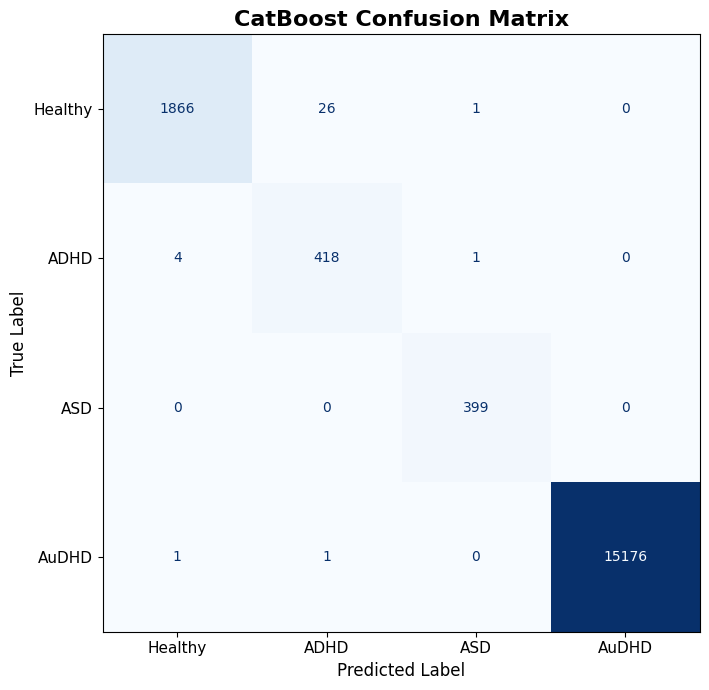

Figure saved to: c:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\outputs\figures\catboost_confusion_matrix.png


In [90]:
plot_confusion_matrix(
    cat_cm,
    class_names,
    "CatBoost Confusion Matrix"
)

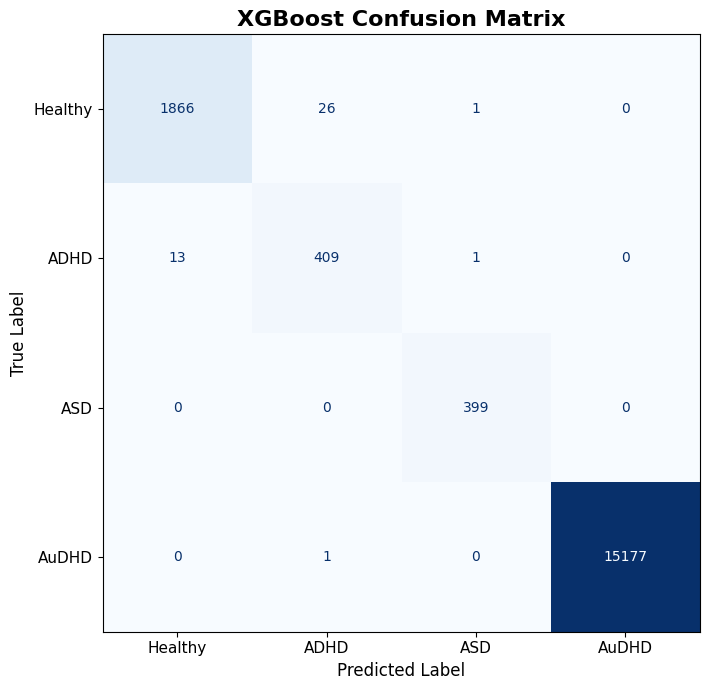

Figure saved to: c:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\outputs\figures\xgboost_confusion_matrix.png


In [91]:
plot_confusion_matrix(
    xgb_cm,
    class_names,
    "XGBoost Confusion Matrix"
)

In [92]:
import importlib

import src.optimization.visualization as visualization

importlib.reload(visualization)

from src.optimization.visualization import plot_multiclass_roc

print("Reload successful!")

Reload successful!


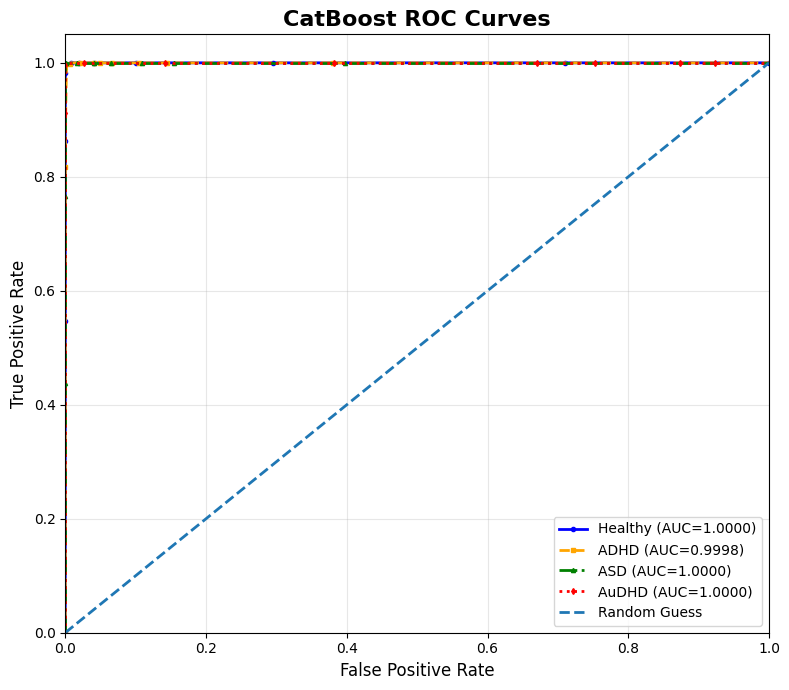

Figure saved to: c:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\outputs\figures\catboost_roc_curves.png


In [93]:
# =============================================================================
# SECTION 37.2 : ROC Curves
# =============================================================================

plot_multiclass_roc(
    cat_model,
    X_test_final,
    y_test_encoded,
    class_names,
    "CatBoost ROC Curves"
)

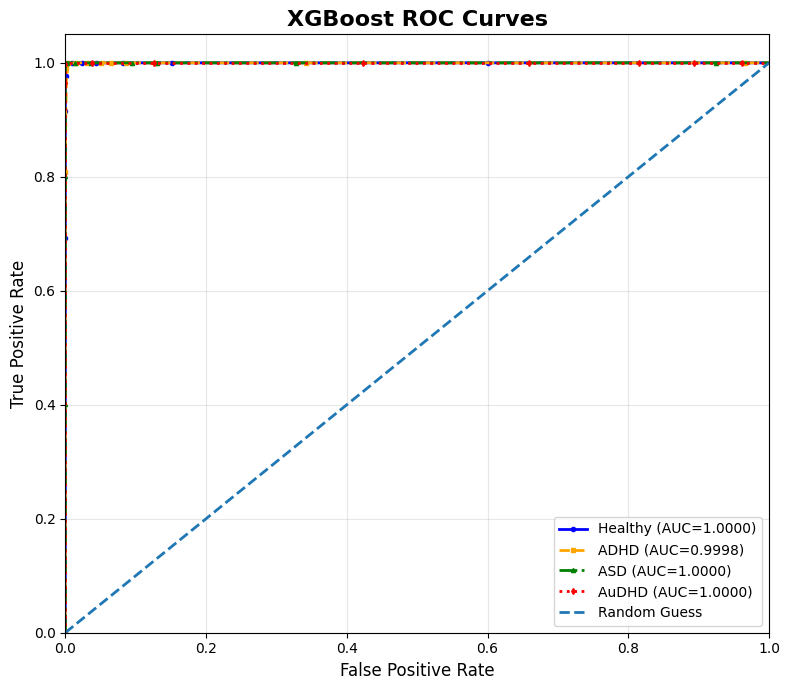

Figure saved to: c:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\outputs\figures\xgboost_roc_curves.png


In [94]:
plot_multiclass_roc(
    xgb_model,
    X_test_final,
    y_test_encoded,
    class_names,
    "XGBoost ROC Curves"
)

In [95]:
# =============================================================================
# SECTION 37.3 : Model Comparison
# =============================================================================

import pandas as pd

comparison_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Balanced Accuracy",
        "MCC"
    ],

    "CatBoost":[
        cat_metrics["Accuracy"],
        cat_metrics["Precision"],
        cat_metrics["Recall"],
        cat_metrics["F1-Score"],
        cat_metrics["ROC-AUC"],
        cat_metrics["PR-AUC"],
        cat_metrics["Balanced Accuracy"],
        cat_metrics["MCC"]
    ],

    "XGBoost":[
        xgb_metrics["Accuracy"],
        xgb_metrics["Precision"],
        xgb_metrics["Recall"],
        xgb_metrics["F1-Score"],
        xgb_metrics["ROC-AUC"],
        xgb_metrics["PR-AUC"],
        xgb_metrics["Balanced Accuracy"],
        xgb_metrics["MCC"]
    ]

})

comparison_df

,Metric,CatBoost,XGBoost
0,Accuracy,0.998100,0.997653
1,Precision,0.982916,0.981542
2,Recall,0.993446,0.988144
3,F1-Score,0.988017,0.984783
4,ROC-AUC,0.999939,0.999934
5,PR-AUC,0.998005,0.997587
6,Balanced Accuracy,0.993446,0.988144
7,MCC,0.992926,0.991254


In [96]:
from pathlib import Path

# Project root directory
PROJECT_ROOT = Path.cwd().parent

# outputs/tables directory
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

# Create it if it doesn't exist
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(TABLE_DIR)

c:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\outputs\tables


In [97]:
comparison_df.to_csv(
    TABLE_DIR / "model_comparison.csv",
    index=False
)

print("Model comparison table saved successfully!")

Model comparison table saved successfully!


In [98]:
# =============================================================================
# SECTION 38 : SHAP Explainability
# =============================================================================

import numpy as np
import shap

print("SHAP Version:", shap.__version__)

SHAP Version: 0.49.1


In [99]:
X_shap = X_test_final.iloc[:1000]

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values_plot = np.mean(np.abs(np.stack(shap_values, axis=-1)), axis=-1)
elif getattr(shap_values, "ndim", 0) == 3:
    shap_values_plot = np.mean(np.abs(shap_values), axis=2)
else:
    shap_values_plot = shap_values

print("SHAP Values Computed!")

SHAP Values Computed!


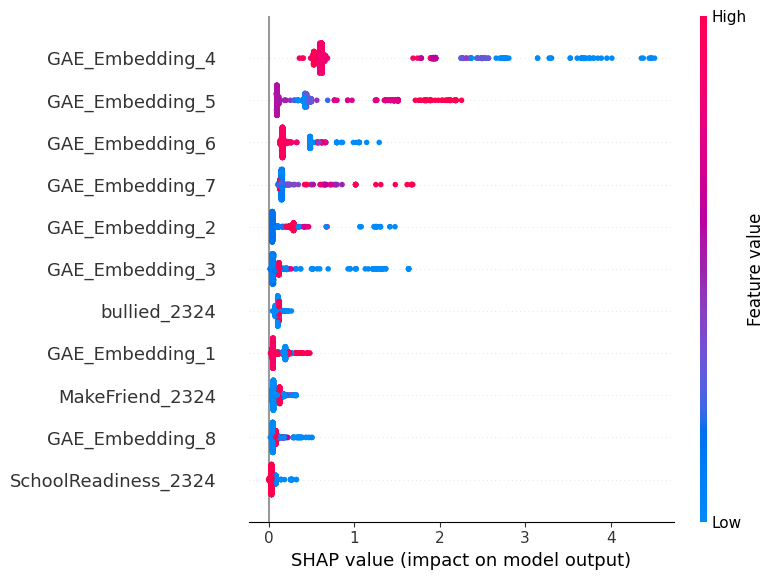

SHAP Summary Plot saved successfully!


In [100]:
# =============================================================================
# SECTION 38.1 : SHAP Summary Plot
# =============================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_plot,
    X_shap,
    show=False
)

plt.tight_layout()
plt.savefig(
    TABLE_DIR.parent / "figures" / "catboost_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP Summary Plot saved successfully!")

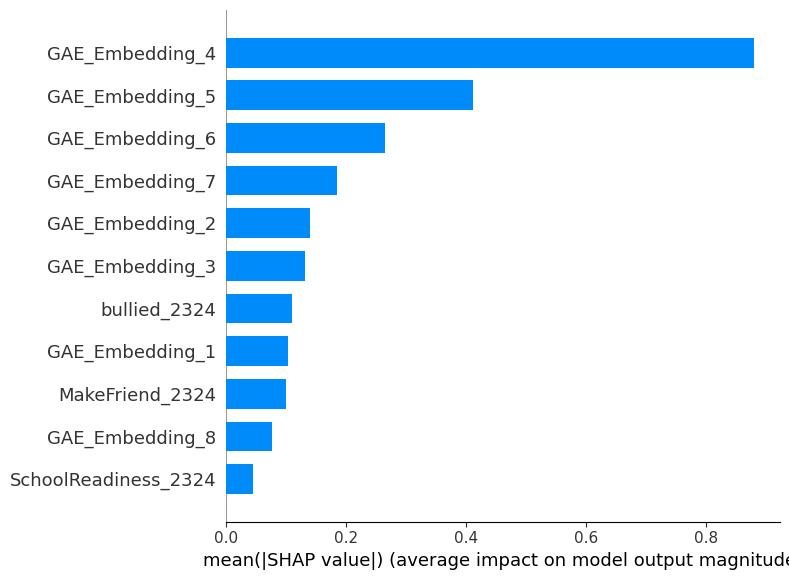

SHAP Bar Plot saved successfully!


In [101]:
# =============================================================================
# SECTION 38.2 : SHAP Bar Plot
# =============================================================================

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_plot,
    X_shap,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    TABLE_DIR.parent / "figures" / "catboost_shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP Bar Plot saved successfully!")

In [102]:
# =============================================================================
# SECTION 38.3 : Export SHAP Feature Importance
# =============================================================================

import numpy as np
import pandas as pd

# Mean absolute SHAP value
mean_shap = np.abs(shap_values_plot).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_SHAP": mean_shap
})

shap_importance = shap_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean_SHAP
0,GAE_Embedding_4,0.879400
1,GAE_Embedding_5,0.411292
3,GAE_Embedding_6,0.265056
2,GAE_Embedding_7,0.183957
4,GAE_Embedding_2,0.139487
5,GAE_Embedding_3,0.130586
9,bullied_2324,0.108773
6,GAE_Embedding_1,0.102218
8,MakeFriend_2324,0.099126
7,GAE_Embedding_8,0.076919


In [103]:
shap_importance.to_csv(
    TABLE_DIR / "shap_feature_importance.csv",
    index=False
)

print("SHAP Feature Importance saved successfully!")

SHAP Feature Importance saved successfully!


In [104]:
from pathlib import Path

MODEL_DIR = PROJECT_ROOT / "models"

print(MODEL_DIR)

c:\Users\DEEP KUMAR GHOSH\Desktop\DGMF-Net-ADHD-ASD\models


In [105]:
cat_model.save_model(
    MODEL_DIR / "catboost_model.cbm"
)

print("✅ CatBoost model saved!")

✅ CatBoost model saved!


In [106]:
xgb_model.save_model(
    MODEL_DIR / "xgboost_model.json"
)

print("✅ XGBoost model saved!")

✅ XGBoost model saved!


In [107]:
import joblib

joblib.dump(
    label_encoder,
    MODEL_DIR / "label_encoder.pkl"
)

print("✅ Label Encoder saved!")

✅ Label Encoder saved!


In [108]:
joblib.dump(
    stable_features,
    MODEL_DIR / "stable_features.pkl"
)

print("✅ Stable Features saved!")

✅ Stable Features saved!


In [109]:
best_parameters = {
    "CatBoost": best_trial_cat.params,
    "XGBoost": best_trial_xgb.params
}

joblib.dump(
    best_parameters,
    MODEL_DIR / "best_hyperparameters.pkl"
)

print("✅ Best Hyperparameters saved!")

✅ Best Hyperparameters saved!


In [110]:
# =============================================================================
# SECTION 40 : Save Final Results
# =============================================================================

metrics_df = pd.DataFrame({
    "Metric": list(cat_metrics.keys()),
    "CatBoost": list(cat_metrics.values()),
    "XGBoost": list(xgb_metrics.values())
})

metrics_df = metrics_df.round(5)

metrics_df.to_csv(
    TABLE_DIR / "evaluation_metrics.csv",
    index=False
)

print("Evaluation metrics saved successfully!")

Evaluation metrics saved successfully!


In [111]:
cat_report_df = pd.DataFrame(cat_report).transpose()

xgb_report_df = pd.DataFrame(xgb_report).transpose()

cat_report_df.to_csv(
    TABLE_DIR / "catboost_classification_report.csv"
)

xgb_report_df.to_csv(
    TABLE_DIR / "xgboost_classification_report.csv"
)

print("Classification reports saved successfully!")

Classification reports saved successfully!


In [112]:
# =============================================================================
# SECTION 41 : Final Project Summary & Verification
# =============================================================================


from pathlib import Path
import os

print("=" * 80)
print("FINAL PROJECT VERIFICATION")
print("=" * 80)

PROJECT_ROOT = Path.cwd().parent

folders = [
    "models",
    "outputs/figures",
    "outputs/tables",
    "outputs/logs",
    "outputs/reports"
]

for folder in folders:

    folder_path = PROJECT_ROOT / folder

    print(f"\n{folder}")

    if folder_path.exists():

        files = os.listdir(folder_path)

        if len(files) == 0:

            print("   Empty")

        else:

            for file in files:

                print(f"   {file}")

    else:

        print("   Folder not found")

FINAL PROJECT VERIFICATION

models
   best_hyperparameters.pkl
   catboost_model.cbm
   label_encoder.pkl
   stable_features.pkl
   xgboost_model.json

outputs/figures
   catboost_confusion_matrix.png
   catboost_roc_curves.png
   catboost_shap_bar.png
   catboost_shap_summary.png
   xgboost_confusion_matrix.png
   xgboost_roc_curves.png

outputs/tables
   catboost_classification_report.csv
   evaluation_metrics.csv
   final_summary.csv
   missing_values.csv
   model_comparison.csv
   numerical_summary.csv
   shap_feature_importance.csv
   xgboost_classification_report.csv

outputs/logs
   Empty

outputs/reports
   Empty


In [113]:
summary = pd.DataFrame({
    "Model": ["CatBoost", "XGBoost"],
    "Accuracy": [cat_metrics["Accuracy"], xgb_metrics["Accuracy"]],
    "Precision": [cat_metrics["Precision"], xgb_metrics["Precision"]],
    "Recall": [cat_metrics["Recall"], xgb_metrics["Recall"]],
    "F1": [cat_metrics["F1-Score"], xgb_metrics["F1-Score"]],
    "ROC-AUC": [cat_metrics["ROC-AUC"], xgb_metrics["ROC-AUC"]],
    "Balanced Accuracy": [
        cat_metrics["Balanced Accuracy"],
        xgb_metrics["Balanced Accuracy"]
    ],
    "MCC": [cat_metrics["MCC"], xgb_metrics["MCC"]]
})

summary = summary.round(5)

summary.to_csv(
    TABLE_DIR / "final_summary.csv",
    index=False
)

print("Final summary saved successfully!")

Final summary saved successfully!
